In [1]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout,Input,Flatten,Dense,MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batchsize=64

train_datagen= ImageDataGenerator(rescale=1./255, rotation_range=0.2,shear_range=0.2,
    zoom_range=0.2,width_shift_range=0.2,
    height_shift_range=0.2, validation_split=0.2)

train_data= train_datagen.flow_from_directory(r'C:\Users\Muhammad\Desktop\mydata\Train',
                                target_size=(80,80),batch_size=batchsize,class_mode='categorical',subset='training' )

validation_data= train_datagen.flow_from_directory(r'C:\Users\Muhammad\Desktop\mydata\Train',
                                target_size=(80,80),batch_size=batchsize,class_mode='categorical', subset='validation')

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(r'C:\Users\Muhammad\Desktop\mydata\Test',
                                target_size=(80,80),batch_size=batchsize,class_mode='categorical')

Found 930 images belonging to 2 classes.
Found 232 images belonging to 2 classes.
Found 290 images belonging to 2 classes.


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout,Input,Flatten,Dense,MaxPooling2D


bmodel = InceptionV3(include_top=False, weights='imagenet', input_tensor=Input(shape=(80,80,3)))
hmodel = bmodel.output
hmodel = Flatten()(hmodel)
hmodel = Dense(units=796, activation='relu')(hmodel)
hmodel = Dropout(0.6)(hmodel)

hmodel = Dense(units=348, activation='relu')(hmodel)
hmodel = Dropout(0.6)(hmodel)

hmodel = Dense(units=192, activation='relu')(hmodel)
hmodel = Dense(units=96, activation='relu')(hmodel)


hmodel = Dense(units=2, activation='softmax')(hmodel)


model = Model(inputs=bmodel.input, outputs=hmodel)

for layer in bmodel.layers:
    layer.trainable = False

In [3]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping, ReduceLROnPlateau
checkpoint = ModelCheckpoint(r'C:\Users\Muhammad\Desktop\code\model4.h5',
                            monitor='val_loss',save_best_only=True,verbose=3)

earlystop = EarlyStopping(monitor = 'val_loss', patience=7, verbose= 3, restore_best_weights=True)

learning_rate = ReduceLROnPlateau(monitor= 'val_loss', patience=3, verbose= 3, )

callbacks=[checkpoint,earlystop,learning_rate]

In [4]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit_generator(train_data,steps_per_epoch=train_data.samples//batchsize,
                   validation_data=validation_data,
                   validation_steps=validation_data.samples//batchsize,
                              callbacks=callbacks,
                    epochs=12)

C:\Users\Muhammad\AppData\Local\Temp\ipykernel_10396\1483998558.py:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(train_data,steps_per_epoch=train_data.samples//batchsize,


Epoch 1/12
7/7 [==============================] - ETA: 0s - loss: 0.6627 - accuracy: 0.6295
Epoch 1: val_loss improved from inf to 0.45382, saving model to C:\Users\Muhammad\Desktop\code\model4.h5


C:\Users\Muhammad\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


7/7 [==============================] - 45s 6s/step - loss: 0.6627 - accuracy: 0.6295 - val_loss: 0.4538 - val_accuracy: 0.7891 - lr: 0.0010
Epoch 2/12
7/7 [==============================] - ETA: 0s - loss: 0.3633 - accuracy: 0.8441
Epoch 2: val_loss improved from 0.45382 to 0.29395, saving model to C:\Users\Muhammad\Desktop\code\model4.h5
7/7 [==============================] - 39s 5s/step - loss: 0.3633 - accuracy: 0.8441 - val_loss: 0.2939 - val_accuracy: 0.8984 - lr: 0.0010
Epoch 3/12
7/7 [==============================] - ETA: 0s - loss: 0.2687 - accuracy: 0.8890
Epoch 3: val_loss improved from 0.29395 to 0.24683, saving model to C:\Users\Muhammad\Desktop\code\model4.h5
7/7 [==============================] - 39s 5s/step - loss: 0.2687 - accuracy: 0.8890 - val_loss: 0.2468 - val_accuracy: 0.9062 - lr: 0.0010
Epoch 4/12
7/7 [==============================] - ETA: 0s - loss: 0.2300 - accuracy: 0.9077
Epoch 4: val_loss improved from 0.24683 to 0.23821, saving model to C:\Users\Muhammad\

In [5]:
acc_test, loss_test = model.evaluate(test_data)
print(acc_test)
print(loss_test)

3/3 [==============================] - 11s 3s/step - loss: 0.0595 - accuracy: 0.9759
0.0595000684261322
0.9758620858192444


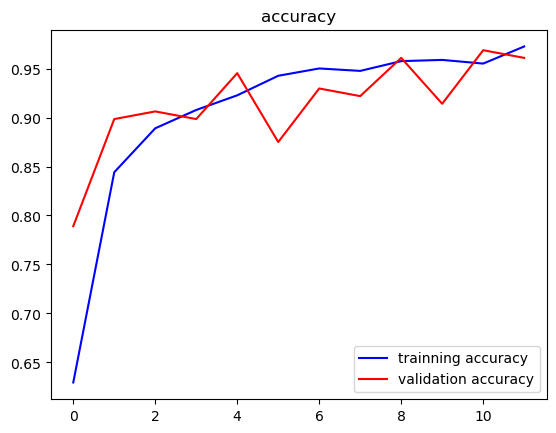

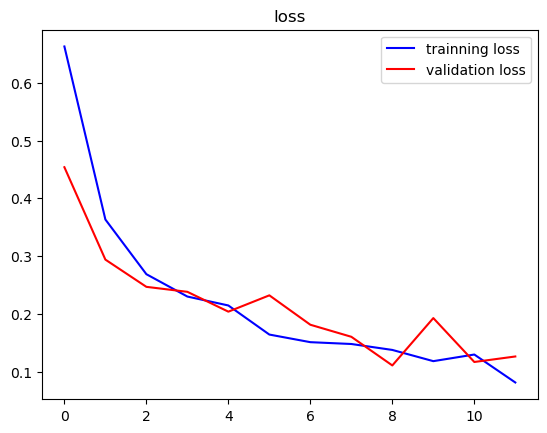

In [10]:
import matplotlib.pyplot as plt

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy , "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.title('accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.title('loss')
plt.legend()
plt.show()

In [22]:
model.save('my__model.keras')

In [10]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 80, 80, 3)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 39, 39, 32)           864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 39, 39, 32)           96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 39, 39, 32)           0         ['batch_normalization[0][0

 conv2d_11 (Conv2D)          (None, 7, 7, 32)             6144      ['average_pooling2d[0][0]']   
                                                                                                  
 batch_normalization_5 (Bat  (None, 7, 7, 64)             192       ['conv2d_5[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 batch_normalization_7 (Bat  (None, 7, 7, 64)             192       ['conv2d_7[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 batch_normalization_10 (Ba  (None, 7, 7, 96)             288       ['conv2d_10[0][0]']           
 tchNormalization)                                                                                
          

                                                                                                  
 activation_17 (Activation)  (None, 7, 7, 96)             0         ['batch_normalization_17[0][0]
                                                                    ']                            
                                                                                                  
 activation_18 (Activation)  (None, 7, 7, 64)             0         ['batch_normalization_18[0][0]
                                                                    ']                            
                                                                                                  
 mixed1 (Concatenate)        (None, 7, 7, 288)            0         ['activation_12[0][0]',       
                                                                     'activation_14[0][0]',       
                                                                     'activation_17[0][0]',       
          

                                                                                                  
 conv2d_28 (Conv2D)          (None, 7, 7, 96)             55296     ['activation_27[0][0]']       
                                                                                                  
 batch_normalization_28 (Ba  (None, 7, 7, 96)             288       ['conv2d_28[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_28 (Activation)  (None, 7, 7, 96)             0         ['batch_normalization_28[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_26 (Conv2D)          (None, 3, 3, 384)            995328    ['mixed2[0][0]']              
          

 conv2d_30 (Conv2D)          (None, 3, 3, 192)            147456    ['mixed3[0][0]']              
                                                                                                  
 conv2d_33 (Conv2D)          (None, 3, 3, 192)            172032    ['activation_32[0][0]']       
                                                                                                  
 conv2d_38 (Conv2D)          (None, 3, 3, 192)            172032    ['activation_37[0][0]']       
                                                                                                  
 conv2d_39 (Conv2D)          (None, 3, 3, 192)            147456    ['average_pooling2d_3[0][0]'] 
                                                                                                  
 batch_normalization_30 (Ba  (None, 3, 3, 192)            576       ['conv2d_30[0][0]']           
 tchNormalization)                                                                                
          

...

                                                                                                  
 activation_52 (Activation)  (None, 3, 3, 160)            0         ['batch_normalization_52[0][0]
                                                                    ']                            
                                                                                                  
 activation_57 (Activation)  (None, 3, 3, 160)            0         ['batch_normalization_57[0][0]
                                                                    ']                            
                                                                                                  
 average_pooling2d_5 (Avera  (None, 3, 3, 768)            0         ['mixed5[0][0]']              
 gePooling2D)                                                                                     
                                                                                                  
 conv2d_50

 batch_normalization_62 (Ba  (None, 3, 3, 192)            576       ['conv2d_62[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 batch_normalization_67 (Ba  (None, 3, 3, 192)            576       ['conv2d_67[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_62 (Activation)  (None, 3, 3, 192)            0         ['batch_normalization_62[0][0]
                                                                    ']                            
                                                                                                  
 activation_67 (Activation)  (None, 3, 3, 192)            0         ['batch_normalization_67[0][0]
          

                                                                                                  
 conv2d_71 (Conv2D)          (None, 1, 1, 320)            552960    ['activation_70[0][0]']       
                                                                                                  
 conv2d_75 (Conv2D)          (None, 1, 1, 192)            331776    ['activation_74[0][0]']       
                                                                                                  
 batch_normalization_71 (Ba  (None, 1, 1, 320)            960       ['conv2d_71[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 batch_normalization_75 (Ba  (None, 1, 1, 192)            576       ['conv2d_75[0][0]']           
 tchNormalization)                                                                                
          

                                                                                                  
 activation_82 (Activation)  (None, 1, 1, 384)            0         ['batch_normalization_82[0][0]
                                                                    ']                            
                                                                                                  
 activation_83 (Activation)  (None, 1, 1, 384)            0         ['batch_normalization_83[0][0]
                                                                    ']                            
                                                                                                  
 batch_normalization_84 (Ba  (None, 1, 1, 192)            576       ['conv2d_84[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activatio

                                                                                                  
 activation_88 (Activation)  (None, 1, 1, 384)            0         ['batch_normalization_88[0][0]
                                                                    ']                            
                                                                                                  
 activation_91 (Activation)  (None, 1, 1, 384)            0         ['batch_normalization_91[0][0]
                                                                    ']                            
                                                                                                  
 activation_92 (Activation)  (None, 1, 1, 384)            0         ['batch_normalization_92[0][0]
                                                                    ']                            
                                                                                                  
 batch_nor